In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

In [ ]:
df = pd.read_csv('Rent-Data.csv', skiprows=1, na_values=["-", "**"])
df.drop('Unnamed: 4', axis=1, inplace=True)
df["Estimate!!Median gross rent"] = pd.to_numeric(df["Estimate!!Median gross rent"], errors="coerce")
df["Margin of Error!!Median gross rent"] = pd.to_numeric(df["Margin of Error!!Median gross rent"], errors="coerce")
df.head()

,Geography,Geographic Area Name,Estimate!!Median gross rent,Margin of Error!!Median gross rent
0,1400000US01001020100,Census Tract 201; Autauga County; Alabama,1049.0,99.0
1,1400000US01001020200,Census Tract 202; Autauga County; Alabama,897.0,270.0
2,1400000US01001020300,Census Tract 203; Autauga County; Alabama,1035.0,174.0
3,1400000US01001020400,Census Tract 204; Autauga County; Alabama,1048.0,434.0
4,1400000US01001020501,Census Tract 205.01; Autauga County; Alabama,1614.0,439.0


In [ ]:
df[['tract', 'county', 'state']] = df['Geographic Area Name'].str.split(';', expand=True)
df[['tract', 'county', 'state']] = df[['tract', 'county', 'state']].apply(lambda x: x.str.strip())

df.drop(columns=['Geographic Area Name'], inplace=True)
df

,Geography,Estimate!!Median gross rent,Margin of Error!!Median gross rent,tract,county,state
0,1400000US01001020100,1049.0,99.0,Census Tract 201,Autauga County,Alabama
1,1400000US01001020200,897.0,270.0,Census Tract 202,Autauga County,Alabama
2,1400000US01001020300,1035.0,174.0,Census Tract 203,Autauga County,Alabama
3,1400000US01001020400,1048.0,434.0,Census Tract 204,Autauga County,Alabama
4,1400000US01001020501,1614.0,439.0,Census Tract 205.01,Autauga County,Alabama
...,...,...,...,...,...,...
85377,1400000US72153750501,551.0,74.0,Census Tract 7505.01,Yauco Municipio,Puerto Rico
85378,1400000US72153750502,229.0,221.0,Census Tract 7505.02,Yauco Municipio,Puerto Rico
85379,1400000US72153750503,668.0,168.0,Census Tract 7505.03,Yauco Municipio,Puerto Rico
85380,1400000US72153750601,747.0,217.0,Census Tract 7506.01,Yauco Municipio,Puerto Rico


In [ ]:
df['geoid'] = df['Geography'].str.extract(r'US(\d{5})')
df['geoid_tract'] = df['Geography'].str.extract(r'US(\d+)')
df.drop(columns=['Geography'], inplace=True)
df

,Estimate!!Median gross rent,Margin of Error!!Median gross rent,tract,county,state,geoid,geoid_tract
0,1049.0,99.0,Census Tract 201,Autauga County,Alabama,01001,01001020100
1,897.0,270.0,Census Tract 202,Autauga County,Alabama,01001,01001020200
2,1035.0,174.0,Census Tract 203,Autauga County,Alabama,01001,01001020300
3,1048.0,434.0,Census Tract 204,Autauga County,Alabama,01001,01001020400
4,1614.0,439.0,Census Tract 205.01,Autauga County,Alabama,01001,01001020501
...,...,...,...,...,...,...,...
85377,551.0,74.0,Census Tract 7505.01,Yauco Municipio,Puerto Rico,72153,72153750501
85378,229.0,221.0,Census Tract 7505.02,Yauco Municipio,Puerto Rico,72153,72153750502
85379,668.0,168.0,Census Tract 7505.03,Yauco Municipio,Puerto Rico,72153,72153750503
85380,747.0,217.0,Census Tract 7506.01,Yauco Municipio,Puerto Rico,72153,72153750601


In [ ]:
df["Estimate!!Median gross rent"] = pd.to_numeric(df["Estimate!!Median gross rent"], errors="coerce")
df["Margin of Error!!Median gross rent"] = pd.to_numeric(df["Margin of Error!!Median gross rent"], errors="coerce")
df = df.rename(columns={'Estimate!!Median gross rent': 'median_rent', 'Margin of Error!!Median gross rent': 'median_rent_moe'})
df

,median_rent,median_rent_moe,tract,county,state,geoid,geoid_tract
0,1049.0,99.0,Census Tract 201,Autauga County,Alabama,01001,01001020100
1,897.0,270.0,Census Tract 202,Autauga County,Alabama,01001,01001020200
2,1035.0,174.0,Census Tract 203,Autauga County,Alabama,01001,01001020300
3,1048.0,434.0,Census Tract 204,Autauga County,Alabama,01001,01001020400
4,1614.0,439.0,Census Tract 205.01,Autauga County,Alabama,01001,01001020501
...,...,...,...,...,...,...,...
85377,551.0,74.0,Census Tract 7505.01,Yauco Municipio,Puerto Rico,72153,72153750501
85378,229.0,221.0,Census Tract 7505.02,Yauco Municipio,Puerto Rico,72153,72153750502
85379,668.0,168.0,Census Tract 7505.03,Yauco Municipio,Puerto Rico,72153,72153750503
85380,747.0,217.0,Census Tract 7506.01,Yauco Municipio,Puerto Rico,72153,72153750601


In [ ]:
df.isna().sum()

,0
median_rent,6633
median_rent_moe,6633
tract,0
county,0
state,0
geoid,0
geoid_tract,0


In [ ]:
df.describe()

,median_rent,median_rent_moe
count,78749.000000,78749.000000
mean,1432.478127,266.344423
std,596.502406,261.524518
min,152.000000,4.000000
25%,965.000000,114.000000
50%,1313.000000,185.000000
75%,1790.000000,315.000000
max,3500.000000,3140.000000


In [ ]:
suplement_data = {'state': ['California', 'Florida', 'Georgia', 'Michigan', 'Missouri', 'North Carolina', 'Oklahoma', 'South Carolina', 'Tennessee', 'Texas', 'Virginia', 'Alabama', 'Arkansas', 'Illinois', 'Indiana', 'Kentucky', 'Louisiana', 'Mississippi', 'New Jersey', 'Ohio', 'Pennsylvania', 'West Virginia', 'Wisconsin', 'Alaska', 'Arizona', 'Colorado', 'Connecticut', 'Delaware', 'Hawaii', 'Idaho', 'Iowa', 'Kansas', 'Maine', 'Maryland', 'Massachusetts', 'Minnesota', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire', 'New Mexico', 'New York', 'North Dakota', 'Oregon', 'Rhode Island', 'South Dakota', 'Utah', 'Vermont', 'Washington', 'Wyoming'],
                  'employee1_mean': [256830, 256830, 256830, 256830, 256830, 256830, 256830, 256830, 256830, 256830, 256830, 156000, 156000, 156000, 156000, 156000, 156000, 156000, 156000, 156000, 156000, 156000, 156000, 132000, 132000, 132000, 132000, 132000, 132000, 132000, 132000, 132000, 132000, 132000, 132000, 132000, 132000, 132000, 132000, 132000, 132000, 132000, 132000, 132000, 132000, 132000, 132000, 132000, 132000, 132000],
                  'employee1_sd': [4109, 4109, 4109, 4109, 4109, 4109, 4109, 4109, 4109, 4109, 4109, 660, 660, 660, 660, 660, 660, 660, 660, 660, 660, 660, 660, 660, 660, 660, 660, 660, 660, 660, 660, 660, 660, 660, 660, 660, 660, 660, 660, 660, 660, 660, 660, 660, 660, 660, 660, 660, 660, 660]
                  }
df2 = pd.DataFrame(suplement_data)
df2

,state,employee1_mean,employee1_sd
0,California,256830,4109
1,Florida,256830,4109
2,Georgia,256830,4109
3,Michigan,256830,4109
4,Missouri,256830,4109
5,North Carolina,256830,4109
6,Oklahoma,256830,4109
7,South Carolina,256830,4109
8,Tennessee,256830,4109
9,Texas,256830,4109


In [ ]:
result = df.merge(df2, on='state', how='left')
result.to_csv('tract_lvl_finance.csv', index=False)

In [ ]:
pop_df = pd.read_csv('all_merged.csv')

pop_df = pop_df[['geoid', 'total_population', 'total_population_poverty', 'poverty_rate_pct']]
pop_df.groupby('geoid').sum()

,total_population,total_population_poverty,poverty_rate_pct
geoid,,,
1001,717108.0,83856.0,141.6
1003,7639485.0,936045.0,384.4
1005,222354.0,52740.0,240.3
1007,88020.0,15916.0,80.0
1009,535608.0,72198.0,122.4
...,...,...,...
56037,496140.0,60468.0,148.8
56039,93148.0,4848.0,20.8
56041,62136.0,6621.0,32.4


In [ ]:
flat = result.groupby("geoid").agg(
    county=("county", "first"),
    state=("state", "first"),
    median_rent=("median_rent", "mean"),
    median_rent_moe=("median_rent_moe", "mean"),
    employee1_mean=("employee1_mean", "first"),
    employee1_sd=("employee1_sd", "first")
).reset_index()
flat['geoid'] = flat['geoid'].astype(int)

county = flat.merge(pop_df, on="geoid", how="left")
county.drop_duplicates(inplace=True)
county.reset_index(drop=True, inplace=True)
county

,geoid,county,state,median_rent,median_rent_moe,employee1_mean,employee1_sd,total_population,total_population_poverty,poverty_rate_pct
0,1001,Autauga County,Alabama,1125.785714,268.857143,156000.0,660.0,59759.0,6988.0,11.8
1,1003,Baldwin County,Alabama,1313.023810,267.142857,156000.0,660.0,246435.0,30195.0,12.4
2,1005,Barbour County,Alabama,733.222222,142.555556,156000.0,660.0,24706.0,5860.0,26.7
3,1007,Bibb County,Alabama,887.875000,362.625000,156000.0,660.0,22005.0,3979.0,20.0
4,1009,Blount County,Alabama,825.750000,142.125000,156000.0,660.0,59512.0,8022.0,13.6
...,...,...,...,...,...,...,...,...,...,...
3217,72145,Vega Baja Municipio,Puerto Rico,656.923077,219.076923,NaN,NaN,NaN,NaN,NaN
3218,72147,Vieques Municipio,Puerto Rico,461.000000,89.000000,NaN,NaN,NaN,NaN,NaN
3219,72149,Villalba Municipio,Puerto Rico,552.000000,198.500000,NaN,NaN,NaN,NaN,NaN
3220,72151,Yabucoa Municipio,Puerto Rico,544.555556,118.333333,NaN,NaN,NaN,NaN,NaN


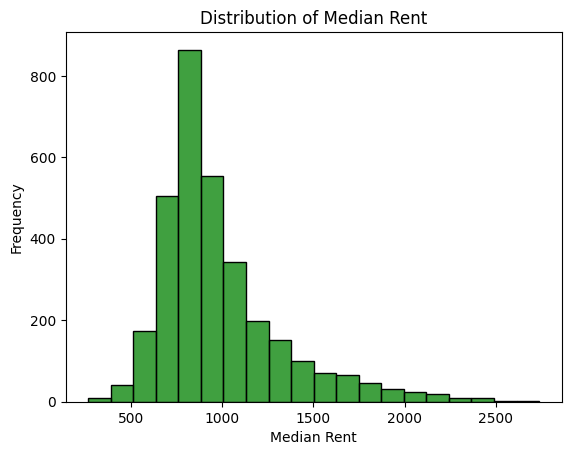

In [ ]:
sns.histplot(county['median_rent'], bins=20, color='green')
plt.xlabel('Median Rent')
plt.ylabel('Frequency')
plt.title('Distribution of Median Rent')
plt.savefig("hist_med_rent.png", dpi=300, bbox_inches="tight")
plt.show()

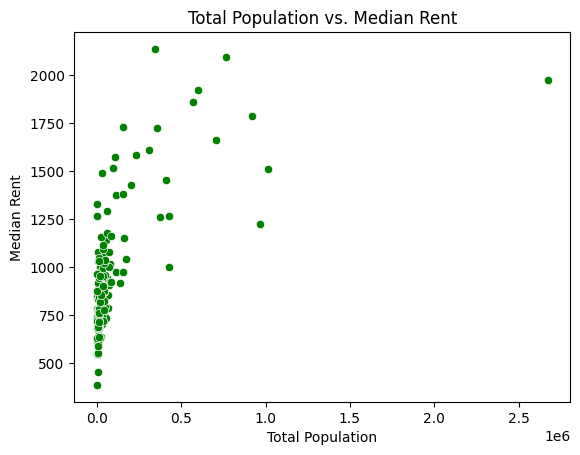

In [ ]:
np.random.seed(30)
sns.scatterplot(x='total_population', y='median_rent', data=county.sample(150), color='green')
plt.xlabel('Total Population')
plt.ylabel('Median Rent')
plt.title('Total Population vs. Median Rent')
plt.savefig("TpVsMr.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
class FinanceCalc:
  def __init__(self, emp_1, emp_extra, rn, rent, count, sub_price):
    self.emp_1 = emp_1
    self.rn = rn
    self.emp_extra = emp_extra
    self.rent = rent
    self.count = count
    self.sub_price = sub_price

  def employee_cost(self):
    amount = self.count
    cost = self.emp_1 + (self.emp_extra*3)
    step = 1

    while amount > 400:
      cost += self.rn
      if step % 2 == 0:
        cost += self.emp_extra
      step += 1
      amount -= 400
    return cost

  def total_cost(self):
    return ((self.employee_cost() + (self.rent*12)) + 15000 + 15000 + 20000)*5

  def roi_percent(self):
    return ((((self.count * self.sub_price * 12)*5) - self.total_cost())/self.total_cost())*100

In [ ]:
test = county.sample()
model = FinanceCalc(test['employee1_mean'].values[0], 45580, 132000, test['median_rent'].values[0], 400, 100)
print(test['county'].values[0], model.roi_percent())

Fayette County 5.071908587439529


In [ ]:
georgia = county[county["state"] == "Georgia"]

georgia["roi"] = georgia.apply(lambda row: FinanceCalc(
    emp_1=row["employee1_mean"],
    emp_extra=45580,
    rn=132000,
    rent=row["median_rent"],
    count=(row["total_population"]*.02),
    sub_price=100
).roi_percent(), axis=1)

georgia

/tmp/ipykernel_11004/1940715503.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  georgia["roi"] = georgia.apply(lambda row: FinanceCalc(


,geoid,county,state,median_rent,median_rent_moe,employee1_mean,employee1_sd,total_population,total_population_poverty,poverty_rate_pct,roi
389,13001,Appling County,Georgia,819.333333,338.833333,256830.0,4109.0,18428.0,3644.0,20.3,-2.454775
390,13003,Atkinson County,Georgia,703.333333,154.333333,256830.0,4109.0,8183.0,1717.0,21.1,-56.551404
391,13005,Bacon County,Georgia,714.000000,143.333333,256830.0,4109.0,11191.0,2485.0,22.9,-40.596897
392,13007,Baker County,Georgia,603.000000,290.500000,256830.0,4109.0,2788.0,599.0,21.6,-85.157252
393,13009,Baldwin County,Georgia,928.769231,223.307692,256830.0,4109.0,43635.0,9253.0,24.1,37.020350
...,...,...,...,...,...,...,...,...,...,...,...
543,13313,Whitfield County,Georgia,984.727273,199.318182,256830.0,4109.0,103132.0,13161.0,12.9,105.144811
544,13315,Wilcox County,Georgia,594.000000,158.500000,256830.0,4109.0,8761.0,1790.0,26.4,-53.347031
545,13317,Wilkes County,Georgia,858.250000,103.250000,256830.0,4109.0,9599.0,1766.0,18.6,-49.241742
546,13319,Wilkinson County,Georgia,867.333333,165.333333,256830.0,4109.0,8681.0,1456.0,17.0,-54.107027


In [ ]:
georgia = county[county["state"] == "Georgia"]
print(georgia[["employee1_mean", "employee1_sd", "extra_emp", "extra_emp_sd","np", "np_sd", "median_rent", "median_rent_moe", "total_population"]].isna().sum())

KeyError: "['extra_emp', 'extra_emp_sd', 'np', 'np_sd'] not in index"

In [ ]:
georgia = county[county["state"] == "Georgia"]
print(len(georgia))
print(georgia["county"].tolist())

159
['Appling County', 'Atkinson County', 'Bacon County', 'Baker County', 'Baldwin County', 'Banks County', 'Barrow County', 'Bartow County', 'Ben Hill County', 'Berrien County', 'Bibb County', 'Bleckley County', 'Brantley County', 'Brooks County', 'Bryan County', 'Bulloch County', 'Burke County', 'Butts County', 'Calhoun County', 'Camden County', 'Candler County', 'Carroll County', 'Catoosa County', 'Charlton County', 'Chatham County', 'Chattahoochee County', 'Chattooga County', 'Cherokee County', 'Clarke County', 'Clay County', 'Clayton County', 'Clinch County', 'Cobb County', 'Coffee County', 'Colquitt County', 'Columbia County', 'Cook County', 'Coweta County', 'Crawford County', 'Crisp County', 'Dade County', 'Dawson County', 'Decatur County', 'DeKalb County', 'Dodge County', 'Dooly County', 'Dougherty County', 'Douglas County', 'Early County', 'Echols County', 'Effingham County', 'Elbert County', 'Emanuel County', 'Evans County', 'Fannin County', 'Fayette County', 'Floyd County', 

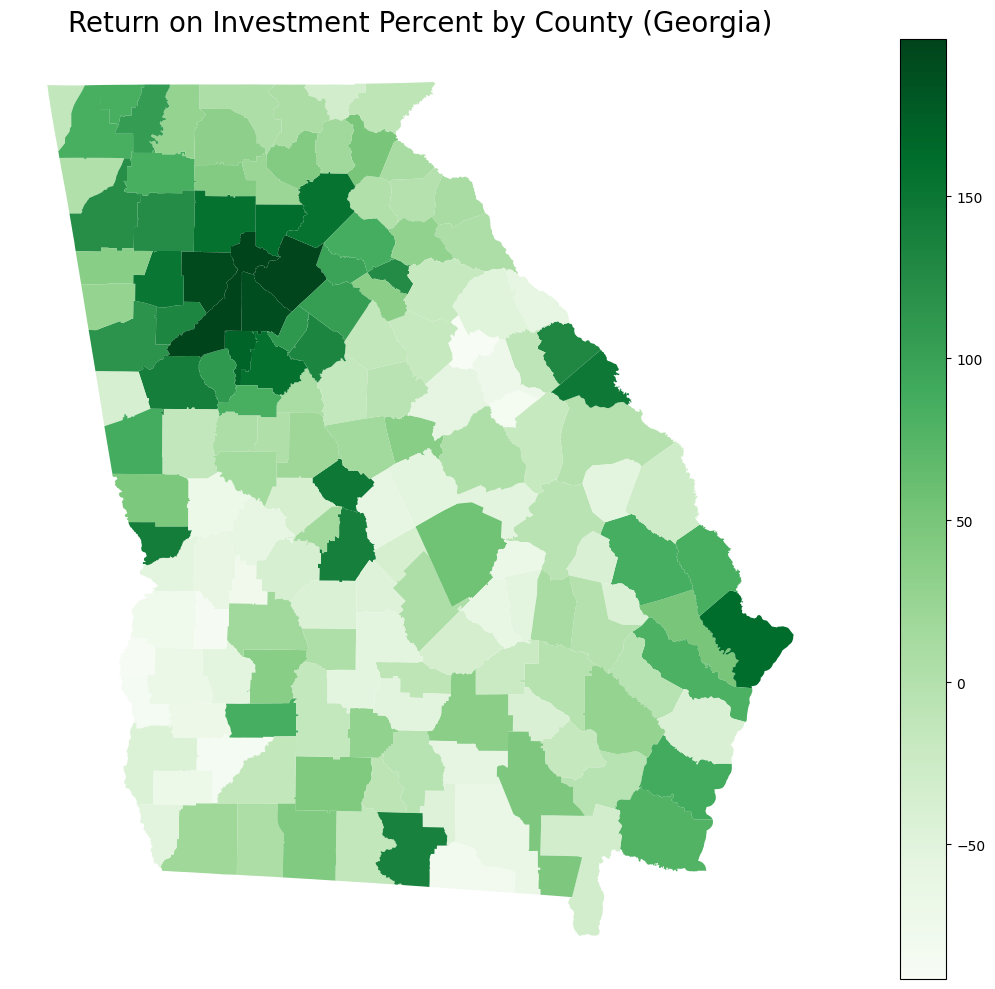

In [ ]:
gdf = gpd.read_file("tl_2020_13_tract.shp")

gdf["geoid"] = (gdf["STATEFP"] + gdf["COUNTYFP"]).astype(int)
county_gdf = gdf.dissolve(by="geoid").reset_index()

merged = county_gdf.merge(georgia[["geoid", "roi"]], on="geoid", how="left")

fig, ax = plt.subplots(1, 1, figsize=(14, 10))
merged.plot(
    column="roi",
    ax=ax,
    legend=True,
    cmap="Greens",
    missing_kwds={"color": "lightgrey", "label": "No Data"}
)
ax.set_title("Return on Investment Percent by County (Georgia)", fontsize=20)
ax.axis("off")
plt.tight_layout()
#plt.savefig("georgia_roi.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
county["roi_2%_adopt"] = county.apply(lambda row: FinanceCalc(
    emp_1=row["employee1_mean"],
    emp_extra=45580,
    rn=132000,
    rent=row["median_rent"],
    count=(row["total_population"]*.02),
    sub_price=100
).roi_percent(), axis=1)

county["roi_1%_adopt"] = county.apply(lambda row: FinanceCalc(
    emp_1=row["employee1_mean"],
    emp_extra=45580,
    rn=132000,
    rent=row["median_rent"],
    count=(row["total_population"]*.01),
    sub_price=100
).roi_percent(), axis=1)

#county.to_csv('roi_by_county.csv')

In [ ]:
county["extra_emp"] = 45580
county["extra_emp_sd"] = 91.16
county["np"] = 132000
county["np_sd"] = 660
county

,geoid,county,state,median_rent,median_rent_moe,employee1_mean,employee1_sd,total_population,total_population_poverty,poverty_rate_pct,roi_2%_adopt,roi_1%_adopt,extra_emp,extra_emp_sd,np,np_sd
0,1001,Autauga County,Alabama,1125.785714,268.857143,156000.0,660.0,59759.0,6988.0,11.8,115.402915,46.873290,45580,91.16,132000,660
1,1003,Baldwin County,Alabama,1313.023810,267.142857,156000.0,660.0,246435.0,30195.0,12.4,166.899968,129.734046,45580,91.16,132000,660
2,1005,Barbour County,Alabama,733.222222,142.555556,156000.0,660.0,24706.0,5860.0,26.7,22.625974,-15.664469,45580,91.16,132000,660
3,1007,Bibb County,Alabama,887.875000,362.625000,156000.0,660.0,22005.0,3979.0,20.0,8.802222,-25.278973,45580,91.16,132000,660
4,1009,Blount County,Alabama,825.750000,142.125000,156000.0,660.0,59512.0,8022.0,13.6,115.678866,47.352826,45580,91.16,132000,660
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3217,72145,Vega Baja Municipio,Puerto Rico,656.923077,219.076923,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45580,91.16,132000,660
3218,72147,Vieques Municipio,Puerto Rico,461.000000,89.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45580,91.16,132000,660
3219,72149,Villalba Municipio,Puerto Rico,552.000000,198.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45580,91.16,132000,660
3220,72151,Yabucoa Municipio,Puerto Rico,544.555556,118.333333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45580,91.16,132000,660


In [ ]:
county["roi_variable"] = county.apply(lambda row: FinanceCalc(
    emp_1= np.random.normal(loc=row["employee1_mean"], scale=row["employee1_sd"]),
    emp_extra= np.random.normal(loc=row["extra_emp"], scale=row["extra_emp_sd"]),
    rn= np.random.normal(loc=row["np"], scale=row["np_sd"]),
    rent= np.random.normal(loc=row["median_rent"], scale=row["median_rent_moe"]),
    count=(row["total_population"]*np.random.uniform(.1, .8)),
    sub_price=100)
.roi_percent(), axis=1)
county

,geoid,county,state,median_rent,median_rent_moe,employee1_mean,employee1_sd,total_population,total_population_poverty,poverty_rate_pct,roi_2%_adopt,roi_1%_adopt,extra_emp,extra_emp_sd,np,np_sd,roi_variable
0,1001,Autauga County,Alabama,1125.785714,268.857143,156000.0,660.0,59759.0,6988.0,11.8,115.402915,46.873290,45580,91.16,132000,660,196.739583
1,1003,Baldwin County,Alabama,1313.023810,267.142857,156000.0,660.0,246435.0,30195.0,12.4,166.899968,129.734046,45580,91.16,132000,660,208.246265
2,1005,Barbour County,Alabama,733.222222,142.555556,156000.0,660.0,24706.0,5860.0,26.7,22.625974,-15.664469,45580,91.16,132000,660,189.011097
3,1007,Bibb County,Alabama,887.875000,362.625000,156000.0,660.0,22005.0,3979.0,20.0,8.802222,-25.278973,45580,91.16,132000,660,189.981440
4,1009,Blount County,Alabama,825.750000,142.125000,156000.0,660.0,59512.0,8022.0,13.6,115.678866,47.352826,45580,91.16,132000,660,205.736990
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3217,72145,Vega Baja Municipio,Puerto Rico,656.923077,219.076923,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45580,91.16,132000,660,NaN
3218,72147,Vieques Municipio,Puerto Rico,461.000000,89.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45580,91.16,132000,660,NaN
3219,72149,Villalba Municipio,Puerto Rico,552.000000,198.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45580,91.16,132000,660,NaN
3220,72151,Yabucoa Municipio,Puerto Rico,544.555556,118.333333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45580,91.16,132000,660,NaN


In [ ]:
import wandb

n_sims = 1000
proj_name = "ROI_monte_carlo"
sub_prices = [120, 100, 80]

for sub_price in sub_prices:

    run = wandb.init(
        project=proj_name,
        name=f"sub_price_{sub_price}",
        config={
            "n_sims":        n_sims,
            "sub_price":     sub_price,
            "adoption_rate": "uniform(0.1, 0.8)",
        },
        reinit=True,
    )

    all_results = []

    for _, row in county.iterrows():
        roi_results = []
        for i in range(n_sims):
            sampled_rent = max(
                np.random.normal(loc=row["median_rent"], scale=row["median_rent_moe"]), 1
            )
            model = FinanceCalc(
                emp_1     = np.random.normal(loc=row["employee1_mean"], scale=row["employee1_sd"]),
                emp_extra = np.random.normal(loc=row["extra_emp"],      scale=row["extra_emp_sd"]),
                rn        = np.random.normal(loc=row["np"],             scale=row["np_sd"]),
                rent      = sampled_rent,
                count     = row["total_population"] * np.random.uniform(0.1, 0.8),
                sub_price = sub_price,
            )
            roi_results.append(model.roi_percent())

        all_results.append({
            "county":    row["county"],
            "state":     row["state"],
            "geoid":     row["geoid"],
            "sub_price": sub_price,
            "roi_mean":  np.mean(roi_results),
            "roi_std":   np.std(roi_results),
            "roi_p10":   np.percentile(roi_results, 10),
            "roi_p50":   np.percentile(roi_results, 50),
            "roi_p90":   np.percentile(roi_results, 90),
        })

    wandb.log({"results": wandb.Table(dataframe=pd.DataFrame(all_results))})

    run.finish()
    print(f"sub_price={sub_price} run complete.")

print("All 3 runs complete.")


sub_price=120 run complete.


sub_price=100 run complete.


sub_price=80 run complete.
All 3 runs complete.


In [ ]:
import wandb

api = wandb.Api()
run = api.run("/mmcgee18-georgia-state-university/ROI_monte_carlo/runs/6f9lywco")
table = run.logged_artifacts()[0].get("results")
df80 = pd.DataFrame(data=table.data, columns=table.columns)

wandb:   1 of 1 files downloaded.  


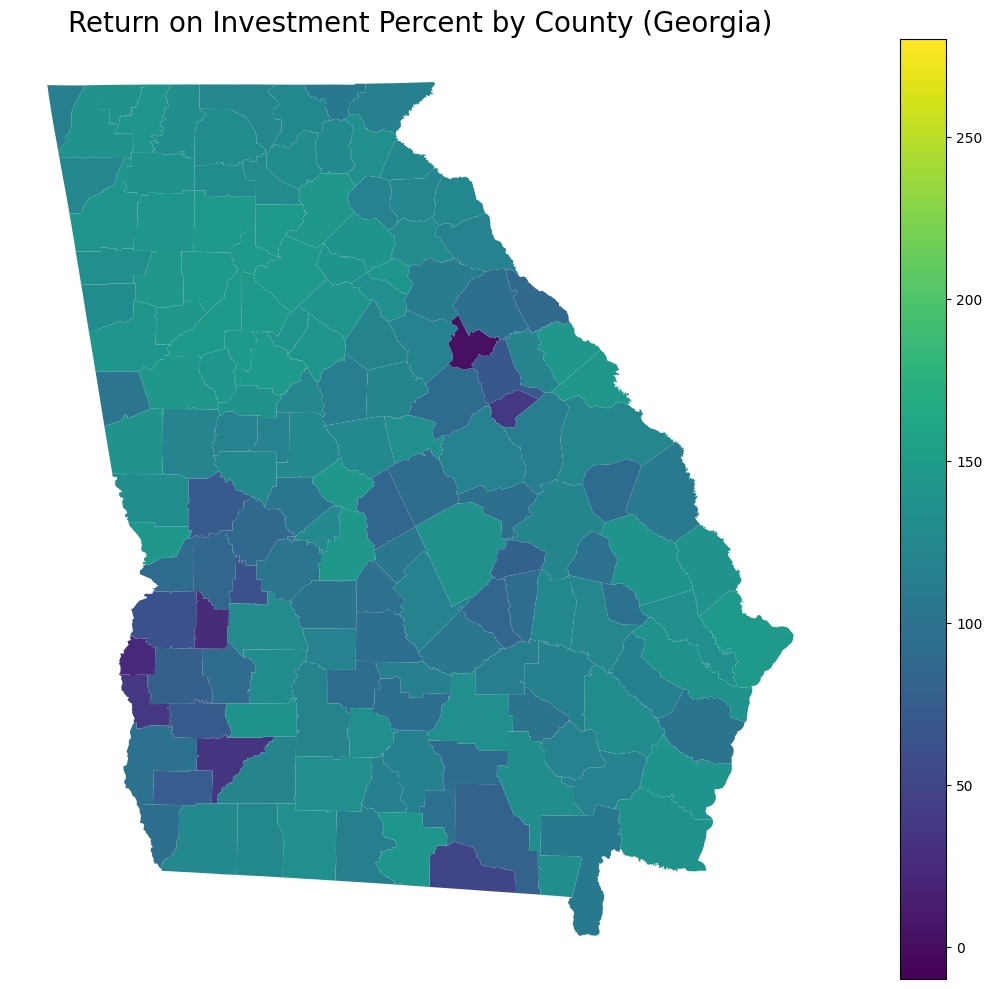

In [ ]:
georgia2 = df80[df80["state"] == "Georgia"]

merged = county_gdf.merge(georgia2[["geoid", "roi_mean"]], on="geoid", how="left")

fig, ax = plt.subplots(1, 1, figsize=(14, 10))
merged.plot(
    column="roi_mean",
    ax=ax,
    legend=True,
    cmap="viridis",
    vmin=-10,
    vmax=280,
    missing_kwds={"color": "lightgrey", "label": "No Data"}
)
ax.set_title("Return on Investment Percent by County (Georgia)", fontsize=20)
ax.axis("off")
plt.tight_layout()
plt.savefig("georgia_roi_80.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
api = wandb.Api()
run = api.run("/mmcgee18-georgia-state-university/ROI_monte_carlo/runs/lxzo2c71")
table = run.logged_artifacts()[0].get("results")
df100 = pd.DataFrame(data=table.data, columns=table.columns)

wandb:   1 of 1 files downloaded.  


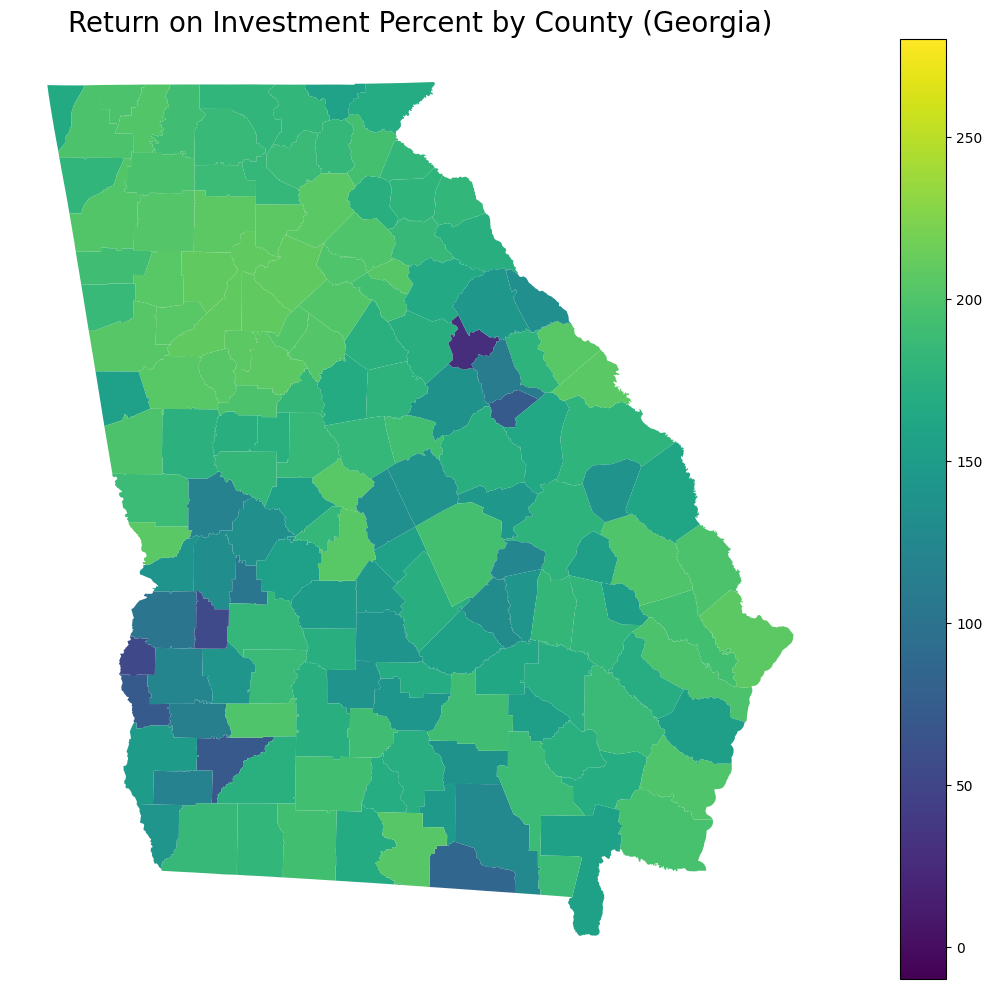

In [ ]:
georgia2 = df100[df100["state"] == "Georgia"]

merged = county_gdf.merge(georgia2[["geoid", "roi_mean"]], on="geoid", how="left")

fig, ax = plt.subplots(1, 1, figsize=(14, 10))
merged.plot(
    column="roi_mean",
    ax=ax,
    legend=True,
    cmap="viridis",
    vmin=-10,
    vmax=280,
    missing_kwds={"color": "lightgrey", "label": "No Data"}
)
ax.set_title("Return on Investment Percent by County (Georgia)", fontsize=20)
ax.axis("off")
plt.tight_layout()
plt.savefig("georgia_roi_100.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
api = wandb.Api()
run = api.run("/mmcgee18-georgia-state-university/ROI_monte_carlo/runs/whp003y2")
table = run.logged_artifacts()[0].get("results")
df120 = pd.DataFrame(data=table.data, columns=table.columns)

wandb:   1 of 1 files downloaded.  


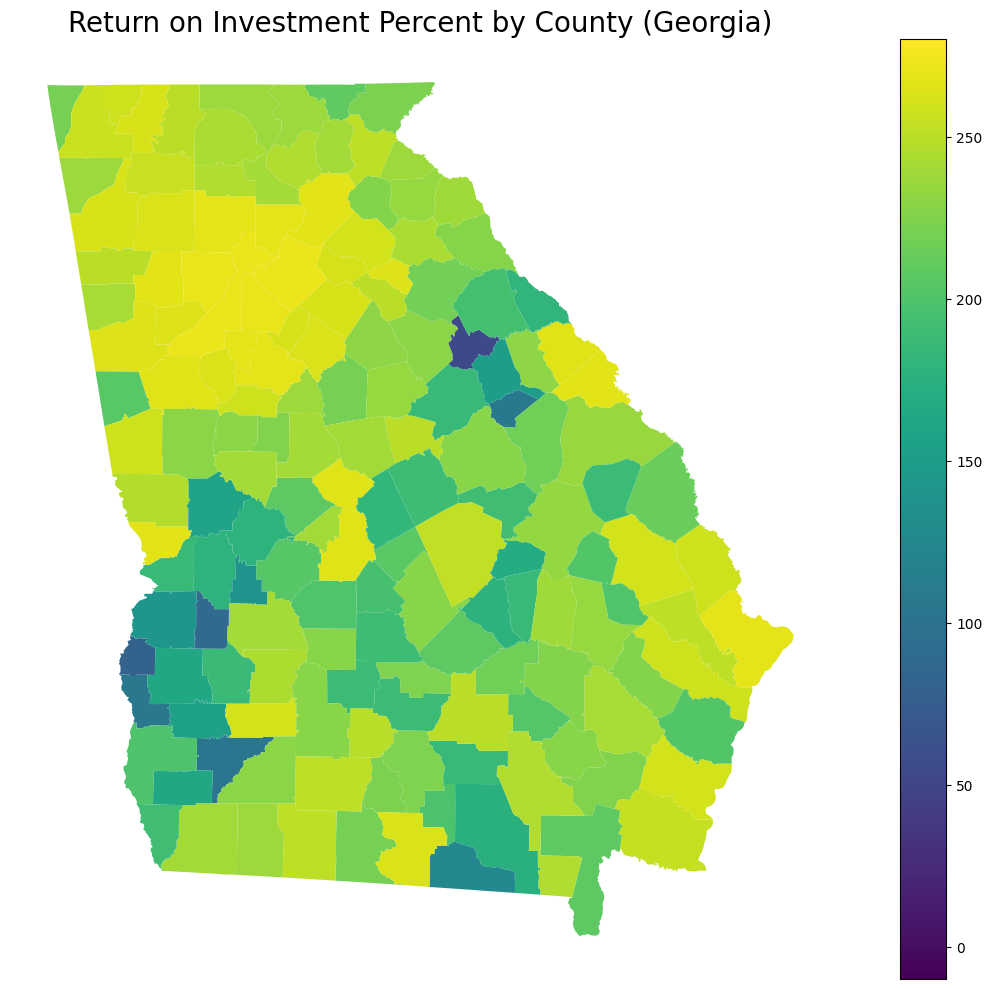

In [ ]:
georgia2 = df120[df120["state"] == "Georgia"]

merged = county_gdf.merge(georgia2[["geoid", "roi_mean"]], on="geoid", how="left")

fig, ax = plt.subplots(1, 1, figsize=(14, 10))
merged.plot(
    column="roi_mean",
    ax=ax,
    legend=True,
    cmap="viridis",
    vmin=-10,
    vmax=280,
    missing_kwds={"color": "lightgrey", "label": "No Data"}
)
ax.set_title("Return on Investment Percent by County (Georgia)", fontsize=20)
ax.axis("off")
plt.tight_layout()
plt.savefig("georgia_roi_120.png", dpi=300, bbox_inches="tight")
plt.show()